##表情データももちいてモデルを構築
# GLM-HMM 解析プロジェクト引継ぎ資料 (Ver.Phase3)

あなたはマウスの行動データ解析プロジェクトのアシスタントです。以下のプロジェクト経緯と技術要件、および実装コードを理解し、続きの解析をサポートしてください。

## 1. プロジェクト概要
* **目的**: マウスの聴覚Go/Wait課題データ（16匹, Day1-15）から、GLM-HMMを用いて潜在的な「内部状態（戦略・覚醒度）」を推定する。
* **現状のフェーズ**: **Phase 3（マルチモーダル拡張）**。行動データ（レバー操作）に加え、ビデオ特徴量（顔・身体の動き）をモデル入力に統合する段階。

## 2. これまでの経緯と課題
* **Phase 1 (初期モデル)**: 状態数K=3, MLE。Action Historyの重みが過剰に肥大化し、スパイク的な遷移しか学習できなかった（過学習）。
* **Phase 2 (正則化)**: 状態数K=2, MAP推定。重みは安定したが、「State 1が単なるAction Historyのコピーになっている」「Engagementが高いはずの状態でStimulusの重みが負になる」という解釈上の問題が発生。
* **Phase 3 (現在の方針)**: 内部状態（Arousal/Attention）をより生理学的に定義するため、ビデオ特徴量を導入する。これにより、単なる運動履歴ではなく、真の脳内状態の遷移を捉えることを目指す。

## 3. データ処理・モデル要件 (決定事項)

### 3.1. モデル入力変数 ( $x_t$: 計13次元)
1.  **Bias**: 固定値 1
2.  **Stimulus**: 音提示区間 (Binary 0/1)
3.  **Action History**: レバー操作の指数減衰履歴 ( $t-1$ ラグ, $\tau \approx 1.0s$)
4.  **Reward History**: 報酬獲得の指数減衰履歴 ( $t-1$ ラグ, $\tau \approx 4.0s$)
5.  **Video Features (9次元)**:
    * **部位**: 耳 (eartip), 目 (medialcorner), 鼻 (nosetip), 口/顎 (lowerjaw) の4箇所 + 瞳孔 (pupil)。
    * **指標**:
        * **Position**: リッキングポート（固定点）からのユークリッド距離 (4特徴量)
        * **Speed**: フレーム間の移動距離 (4特徴量)
        * **Pupil**: 瞳孔径 (1特徴量)

### 3.2. 前処理ルール (Strict Rules)
* **Binning (30Hz -> 10Hz)**:
    * Binaryデータ (Stim, Action, Reward): `max` 集約。
    * 連続値 (Position, Pupil): **`median` (中央値)** 集約。
    * 連続値 (Speed): **`sum` (合計)** 集約（総移動量）。
* **Normalization**:
    * **ビデオ特徴量のみ**、セッションごとに **Z-score正規化** を行う。
    * Bias, Stimulus, History系は正規化しない。
* **Lagging (因果性担保)**:
    * ビデオ特徴量もAction Historyと同様に、**必ず 1ラグ ( $t-1$) ずらして** 入力する（同時刻の運動漏れ込み防止）。

In [ ]:
# ===================================================================
# 共通セットアップセル (ローカル / Colab 共通)
# ===================================================================
import sys
import os
from pathlib import Path

# --- 1. 環境判別 ---
IN_COLAB = False
try:
    # Colab環境でのみインポートが成功する
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    pass # ローカル環境


if IN_COLAB:
    # ==================================
    # Colab 環境でのセットアップ
    # ==================================
    print("環境: Colab を検出。セットアップを開始します。")

    # 1. Google Driveのマウント
    drive.mount('/content/drive')

    # 2. GitHubリポジトリのクローンまたはプル
    repo_path = Path('/content/braidyn-bc')
    if repo_path.exists():
        print("リポジトリを pull します...")
        os.chdir(repo_path)
        !git pull
    else:
        print("リポジトリを clone します...")
        !git clone https://github.com/nyaamikeneko/braidyn-bc.git
        os.chdir(repo_path)

    # 3. 依存ライブラリのインストール
    print("依存ライブラリをインストールします...")
    !pip install -q pynwb git+https://github.com/BraiDyn-BC/bdbc-nwb-explorer.git

    # 4. sys.path の設定
    project_root = repo_path
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))

    print(f"セットアップ完了。プロジェクトルート: {project_root}")

else:
    # ==================================
    # ローカル (VSCode) 環境でのセットアップ
    # ==================================
    print("環境: ローカル (VSCode) を検出。")

    # 1. sys.path の設定
    current_dir = Path.cwd()
    if current_dir.name == 'notebooks':
        # ノートブックが notebooks/ から実行された場合
        project_root = current_dir.parent
    else:
        # プロジェクトルート (braidyn-bc/) から実行されたと仮定
        project_root = current_dir

    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))

    print(f"プロジェクトルート: {project_root}")

# ===================================================================
# 共通インポート・処理
# (セットアップが完了したため、config.py や src/ が読み込める)
# ===================================================================
print("\n共通モジュールをインポートします...")

import bdbc_nwb_explorer as nwbx
import src.data_loader as dl
import config  # config.py もここで読み込める

print(f"データパス (DATA_NWB_ROOT): {config.DATA_NWB_ROOT}")

環境: Colab を検出。セットアップを開始します。
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
リポジトリを pull します...
Already up to date.
依存ライブラリをインストールします...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
セットアップ完了。プロジェクトルート: /content/braidyn-bc

共通モジュールをインポートします...
環境: Colab
データパス (DATA_NWB_ROOT): /content/drive/MyDrive/braidyn-bc/data


In [ ]:
# --- 必要なデータを関数で読み出す ---
SESSION_ID = "VG1GC-66"
NWB_FILENAME = "VG1GC-66_2023-09-08_task-day15.nwb"
TASK_DAY_DIR = "task-day15"

# NWBデータの読み込み
# (dl は共通セルでインポート済み)
session = dl.load_nwb_session(SESSION_ID, NWB_FILENAME)

# CSVデータの読み込み
trials = dl.load_trials_csv(SESSION_ID, TASK_DAY_DIR)


NWB読み込み中: /content/drive/MyDrive/braidyn-bc/data/VG1GC-66/VG1GC-66_2023-09-08_task-day15.nwb
CSV読み込み中: /content/drive/MyDrive/hackathon_data/VG1GC-66/task-day15/trials_L1L2.csv
全試行数: 54000


In [ ]:
!git clone https://github.com/lindermanlab/ssm
!pip install numpy cython
%cd ssm
!pip install -e .
%cd ..

fatal: destination path 'ssm' already exists and is not an empty directory.
/content/braidyn-bc/ssm
Obtaining file:///content/braidyn-bc/ssm
  Preparing metadata (setup.py) ... done
  Attempting uninstall: ssm
    Found existing installation: ssm 0.0.1
    Uninstalling ssm-0.0.1:
      Successfully uninstalled ssm-0.0.1
  Running setup.py develop for ssm


/content/braidyn-bc


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

def generate_glmhmm_dataset(trials_df, session,
                            gap_fill_limit=2, noise_remove_limit=2,
                            bin_width_frames=3, bin_width_sec=0.1,
                            gap_threshold_sec=10.0):

    # =========================================================================
    # Phase 0: Video Feature Extraction (30Hz)
    # =========================================================================

    # 1. データ読み込みと 't' カラムの確保
    try:
        video_df = pd.DataFrame(session.entries.data).copy()

        # 't' がカラムにない場合、インデックスからの復帰を試みる
        if 't' not in video_df.columns:
            if 'time' in video_df.columns:
                video_df = video_df.rename(columns={'time': 't'})
            else:
                video_df = video_df.reset_index() # インデックスが時間の場合
                if 'index' in video_df.columns:
                    video_df = video_df.rename(columns={'index': 't'})

        # それでも 't' がない場合はエラー回避のため空にする
        if 't' not in video_df.columns:
            print("Warning: 't' column not found in video data.")
            video_df = pd.DataFrame()

    except Exception as e:
        print(f"Video Data Read Error: {e}")
        video_df = pd.DataFrame()

    video_features = []

    if not video_df.empty:
        # 部位定義
        parts = {
            'eartip': 'eartip',
            'medialcorner': 'medialcorner',
            'nosetip': 'nosetip',
            'lowerjaw': 'lowerjaw'
        }
        lp_x_col = 'face_video_lickport_x'
        lp_y_col = 'face_video_lickport_y'

        # --- 修正箇所開始 ---

        # 特徴量計算
        for part_key, part_name in parts.items():
            # 変更点: face_video_ 接頭辞を削除し、直接 {part_name}_x を参照
            x_col = f'{part_name}_x'
            y_col = f'{part_name}_y'

            # データが存在する場合のみ計算
            if x_col in video_df.columns and y_col in video_df.columns and lp_x_col in video_df.columns:
                # 位置 (Position): 固定点(Lickport)からの距離
                pos_col = f'feat_pos_{part_key}'
                video_df[pos_col] = np.sqrt(
                    (video_df[x_col] - video_df[lp_x_col])**2 +
                    (video_df[y_col] - video_df[lp_y_col])**2
                )
                video_features.append(pos_col)

                # 速度 (Speed): フレーム間差分
                speed_col = f'feat_speed_{part_key}'
                video_df[speed_col] = np.sqrt(
                    video_df[x_col].diff()**2 + video_df[y_col].diff()**2
                ).fillna(0)
                video_features.append(speed_col)
            else:
                # デバッグ用: どのカラムが見つからなかったか出力しておくと確実です
                pass
                # print(f"Skipping {part_name}: {x_col} or {y_col} not found.")

        # --- 修正箇所終了 ---

        # 瞳孔径
        pupil_col = 'face_video_pupildia'
        if pupil_col not in video_df.columns and 'pupildia' in video_df.columns:
             pupil_col = 'pupildia'
        if pupil_col in video_df.columns:
            target_pupil = 'feat_pupil'
            video_df[target_pupil] = video_df[pupil_col]
            video_features.append(target_pupil)

        # 欠損値補間
        video_df[video_features] = video_df[video_features].interpolate(method='linear').fillna(method='ffill').fillna(0)
        video_subset = video_df[['t'] + video_features].sort_values('t')
    else:
        video_subset = pd.DataFrame()

    # =========================================================================
    # Phase 1: Behavior Data Cleaning (30Hz)
    # =========================================================================

    df = trials_df.copy()

    # NWBデータ処理 (Reward取得)
    try:
        nwb_data = session.nwb if hasattr(session, 'nwb') else session
        if hasattr(nwb_data, 'trials') and hasattr(nwb_data.trials, 'to_dataframe'):
            nwb_trials_df = nwb_data.trials.to_dataframe()
        else:
            nwb_trials_df = pd.DataFrame(nwb_data.trials.data) if hasattr(nwb_data, 'trials') else pd.DataFrame()
    except:
        nwb_trials_df = pd.DataFrame()

    def filter_consecutive_runs(series, target_val, max_len, fill_val):
        groups = (series != series.shift()).cumsum()
        counts = series.groupby(groups).transform('count')
        mask = (series == target_val) & (counts <= max_len)
        series[mask] = fill_val
        return series

    df['cleaned_lever'] = df['state_lever'].fillna(0).astype(int)
    df['cleaned_lever'] = filter_consecutive_runs(df['cleaned_lever'], 0, gap_fill_limit, 1)
    df['cleaned_lever'] = filter_consecutive_runs(df['cleaned_lever'], 1, noise_remove_limit, 0)

    df['stimulus'] = 0
    df['action'] = 0
    df['reward'] = 0

    if 'state_task' in df.columns:
        df.loc[df['state_task'] == 1, 'stimulus'] = 1

    lever_diff = df['cleaned_lever'].diff()
    df.loc[lever_diff == 1, 'action'] = 1

    if not nwb_trials_df.empty and 'trial_outcome' in nwb_trials_df.columns:
        success_trials = nwb_trials_df[nwb_trials_df['trial_outcome'] == 'success'].copy()
        if not success_trials.empty:
            reward_targets = pd.DataFrame({
                'reward_t': success_trials['pull_onset'],
                'flag': 1
            }).sort_values('reward_t')

            df = df.sort_values('t')
            merged = pd.merge_asof(
                df, reward_targets,
                left_on='t', right_on='reward_t',
                direction='nearest', tolerance=0.034
            )
            df['reward'] = merged['flag'].fillna(0).astype(int)

    # Behavior + Video Merge
    if not video_subset.empty:
        df = pd.merge_asof(
            df.sort_values('t'),
            video_subset,
            on='t',
            direction='nearest',
            tolerance=0.034
        )
        df[video_features] = df[video_features].fillna(0)

    # =========================================================================
    # Phase 2: Binning & Feature Engineering (10Hz)
    # =========================================================================

    n_rows = len(df)
    bin_ids = np.arange(n_rows) // bin_width_frames

    # 集約ルールの定義 (ここを修正)
    agg_dict = {
        't': 'min',
        'stimulus': 'max',
        'action': 'max',
        'reward': 'max',
    }

    # Video特徴量ごとの集約ルール設定
    for v_col in video_features:
        if 'speed' in v_col:
            agg_dict[v_col] = 'sum'    # 速度は合計（総移動量）
        else:
            agg_dict[v_col] = 'median' # 位置・瞳孔は中央値

    binned_df = df.groupby(bin_ids).agg(agg_dict).reset_index(drop=True)

    # Reward Debouncing
    rew_vals = binned_df['reward'].values
    mask = (rew_vals[1:] == 1) & (rew_vals[:-1] == 1)
    rew_vals[1:][mask] = 0
    binned_df['reward'] = rew_vals

    # History Calculation
    alpha_act = np.exp(np.log(0.1) / 10)
    alpha_rew = np.exp(np.log(0.1) / 40)

    y = binned_df['action'].values
    r = binned_df['reward'].values
    T = len(y)

    hist_act = np.zeros(T)
    hist_rew = np.zeros(T)
    prev_h_act, prev_h_rew = 0.0, 0.0

    for t in range(1, T):
        hist_act[t] = y[t-1] + alpha_act * prev_h_act
        prev_h_act = hist_act[t]
        hist_rew[t] = r[t-1] + alpha_rew * prev_h_rew
        prev_h_rew = hist_rew[t]

    binned_df['y'] = y
    binned_df['x_bias'] = 1
    binned_df['x_stim'] = binned_df['stimulus']
    binned_df['x_hist'] = hist_act
    binned_df['x_rew']  = hist_rew

    # Normalization & Lagging
    final_video_cols = []
    if video_features:
        # 正規化 (Z-score)
        vals = binned_df[video_features].fillna(0).values
        vals_z = zscore(vals, axis=0, nan_policy='omit')
        vals_z = np.nan_to_num(vals_z)

        # Lagging (t-1)
        lagged_vals = np.zeros_like(vals_z)
        lagged_vals[1:, :] = vals_z[:-1, :]

        for idx, col_name in enumerate(video_features):
            lag_col_name = f'x_{col_name}'
            binned_df[lag_col_name] = lagged_vals[:, idx]
            final_video_cols.append(lag_col_name)

    base_inputs = ['x_bias', 'x_stim', 'x_hist', 'x_rew']
    all_inputs = base_inputs + final_video_cols

    # =========================================================================
    # Phase 3: Split Data by ITI
    # =========================================================================

    gap_bins = int(gap_threshold_sec / bin_width_sec)
    is_active = (binned_df['x_stim'] == 1) | (binned_df['y'] == 1)

    condition = is_active.astype(int)
    groups = (condition != condition.shift()).cumsum()
    group_sizes = condition.groupby(groups).transform('size')
    to_drop = (~is_active) & (group_sizes >= gap_bins)

    valid_df = binned_df[~to_drop].reset_index(drop=True)

    if valid_df.empty:
        return [], [], []

    break_indices = np.where(np.diff(valid_df.index.values) > 1)[0] + 1
    df_splits = np.split(valid_df, break_indices)

    train_dfs = []
    train_ys = []
    train_xs = []

    for sub_df in df_splits:
        if len(sub_df) == 0: continue
        train_dfs.append(sub_df)
        train_ys.append(sub_df[['y']].values.astype(int))
        train_xs.append(sub_df[all_inputs].fillna(0).values.astype(float))

    return train_dfs, train_ys, train_xs

train_dfs, train_ys, train_xs = generate_glmhmm_dataset(trials, session)

/tmp/ipython-input-1607065833.py:90: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  video_df[video_features] = video_df[video_features].interpolate(method='linear').fillna(method='ffill').fillna(0)
/tmp/ipython-input-1607065833.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series[mask] = fill_val
/tmp/ipython-input-1607065833.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  series[mask] = fill_val
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated 

In [ ]:
train_dfs

[                 t  stimulus  action  reward  feat_pos_eartip  \
 0         8.750600         0       0       0       387.290741   
 1         8.850600         0       0       0       387.967377   
 2         8.950600         0       0       0       386.560486   
 3         9.050600         0       0       0       388.801208   
 4         9.150600         0       0       0       387.064423   
 ...            ...       ...     ...     ...              ...   
 17995  1808.262817         0       0       0       395.278687   
 17996  1808.362793         0       0       0       396.119171   
 17997  1808.462769         0       0       0       397.118347   
 17998  1808.562744         0       0       0       397.825256   
 17999  1808.662842         0       0       0       397.434937   
 
        feat_speed_eartip  feat_pos_medialcorner  feat_speed_medialcorner  \
 0               0.774889             191.862289                 1.018481   
 1               5.343766             192.278427    

###L2正規化を実施

Training GLM-HMM (K=3, D=13) with MAP Estimation (prior_sigma=2.0)...


  0%|          | 0/200 [00:00<?, ?it/s]

Seed 0: Final Score (Log Prob) = -1508.88


  0%|          | 0/200 [00:00<?, ?it/s]

Seed 1: Final Score (Log Prob) = -1536.85


  0%|          | 0/200 [00:00<?, ?it/s]

Seed 2: Final Score (Log Prob) = -1508.66

Recovered Weights with Regularization:
State 1 : [ 4.46 -0.32 12.81 -0.2  -0.39 -0.52 -0.79 -0.47  0.92 -0.61  1.07 -0.63
  0.9 ] ...
State 2 : [ 6.26 -0.77  6.2  -2.17 -1.32 -1.22 -0.09  0.35  0.64  0.49  0.19  0.51
  0.87] ...
State 3 : [ 2.45 -1.37  3.08 -0.01  0.02 -0.56  0.05 -0.07 -0.13 -0.44  0.03 -0.44
 -0.47] ...


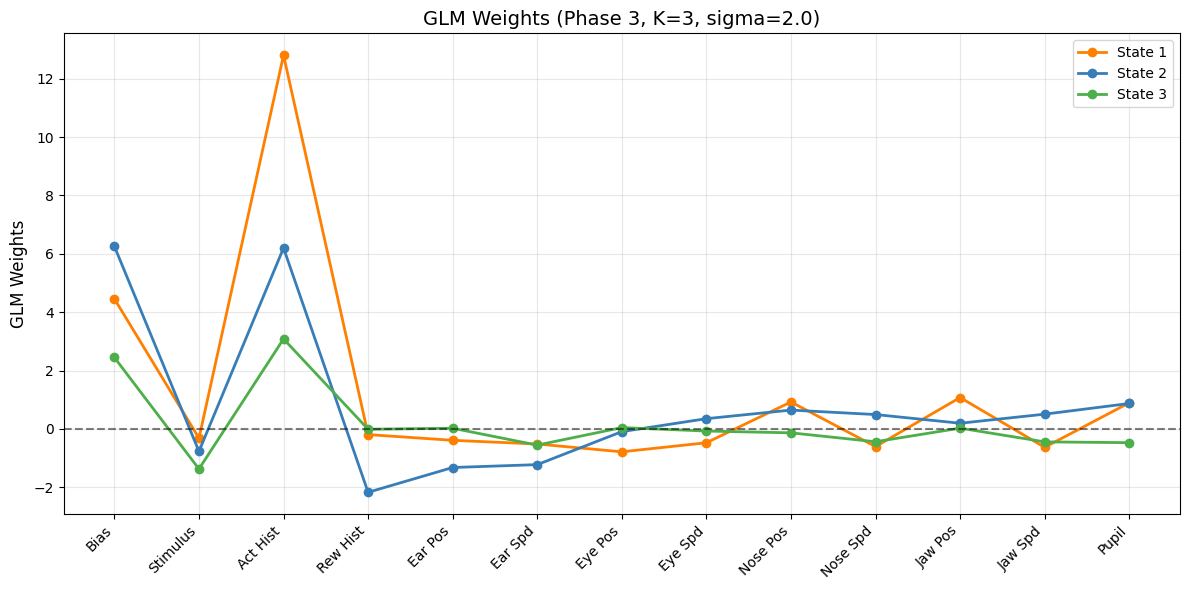


Transition Matrix:
[[0.975 0.002 0.023]
 [0.01  0.99  0.   ]
 [0.22  0.002 0.778]]


In [ ]:
import numpy as np
import ssm
import matplotlib.pyplot as plt

def train_glmhmm_map(train_ys, train_xs, num_states=2, prior_sigma=2.0, num_iters=200, seeds=[0]):
    """
    L2正則化（MAP推定）を用いてGLM-HMMを学習する関数。
    Phase 3対応: 入力次元をデータから自動取得するように変更。
    """

    obs_dim = 1
    # 変更点1: 入力次元を固定値(4)から、データのシェイプに基づいて自動取得するように変更
    # train_xsはリスト形式なので、最初のセッションの列数を参照
    input_dim = train_xs[0].shape[1]
    num_categories = 2

    best_model = None
    best_ll = -np.inf

    print(f"Training GLM-HMM (K={num_states}, D={input_dim}) with MAP Estimation (prior_sigma={prior_sigma})...")

    for seed in seeds:
        np.random.seed(seed)

        glmhmm = ssm.HMM(
            K=num_states,
            D=obs_dim,
            M=input_dim,
            observations="input_driven_obs",
            observation_kwargs=dict(
                C=num_categories,
                prior_mean=0,
                prior_sigma=prior_sigma
            ),
            transitions="standard"
        )

        try:
            lls = glmhmm.fit(train_ys, inputs=train_xs, method="em", num_iters=num_iters, tolerance=10**-4)
            final_score = lls[-1]
            print(f"Seed {seed}: Final Score (Log Prob) = {final_score:.2f}")

            if final_score > best_ll:
                best_ll = final_score
                best_model = glmhmm

        except Exception as e:
            print(f"Seed {seed} failed: {e}")
            continue

    if best_model is None:
        raise RuntimeError("Training failed.")

    return best_model

# --- 実行と確認 ---
try:
    # 状態数K=3推奨（Phase 3方針）
    map_model = train_glmhmm_map(train_ys, train_xs, num_states=3, prior_sigma=2.0, seeds=[0, 1, 2])

    # --- 重みの確認 ---
    glm_weights_map = map_model.observations.params

    # 変更点2: Phase 3用の特徴量名リスト (計13個) を定義
    # 順序は generate_glmhmm_dataset の結合順序に依存します
    # Base(4) + Video(9): Ear(P,S), Eye(P,S), Nose(P,S), Jaw(P,S), Pupil
    feature_names = [
        'Bias', 'Stimulus', 'Act Hist', 'Rew Hist',
        'Ear Pos', 'Ear Spd',
        'Eye Pos', 'Eye Spd',
        'Nose Pos', 'Nose Spd',
        'Jaw Pos', 'Jaw Spd',
        'Pupil'
    ]

    # 状態数に合わせて色を定義（K=3まで対応）
    colors = ['#ff7f00', '#377eb8', '#4daf4a']

    print("\nRecovered Weights with Regularization:")
    # 各次元の重みを表示（数が多いため、主要なもののみ表示するか、全て表示するか調整可能）
    for k in range(map_model.K):
        # 最初の5つだけ表示する例
        weights_preview = np.round(glm_weights_map[k][0][:], 2)
        print(f"State {k+1} : {weights_preview} ...")

    plt.figure(figsize=(12, 6)) # 変更点3: 横幅を広げて見やすく
    for k in range(map_model.K):
        w_k = glm_weights_map[k][0]
        # input_dimとfeature_namesの長さが一致しているか念のため確認
        if len(w_k) > len(feature_names):
             # 万が一名前が足りない場合はプレースホルダーを追加
             feature_names += [f"Feat {i}" for i in range(len(feature_names), len(w_k))]

        plt.plot(range(len(w_k)), w_k, marker='o',
                 label=f'State {k+1}', color=colors[k] if k < len(colors) else None, linewidth=2)

    plt.axhline(0, color='black', linestyle='--', alpha=0.5)

    # 変更点4: ラベルを見やすく回転
    plt.xticks(range(len(feature_names)), feature_names, fontsize=10, rotation=45, ha='right')

    plt.ylabel("GLM Weights", fontsize=12)
    plt.title(f"GLM Weights (Phase 3, K={map_model.K}, sigma={2.0})", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout() # レイアウト崩れ防止
    plt.show()

    # --- 遷移確率の確認 ---
    print("\nTransition Matrix:")
    print(np.round(np.exp(map_model.transitions.params)[0], 3))

except NameError:
    print("Input data (train_ys, train_xs) not found. Please run generate_glmhmm_dataset first.")
except IndexError as e:
    print(f"Index Error: {e}. Check if feature_names length matches input dimension.")


Transition Matrix (K=3):
[[0.975 0.002 0.023]
 [0.01  0.99  0.   ]
 [0.22  0.002 0.778]]


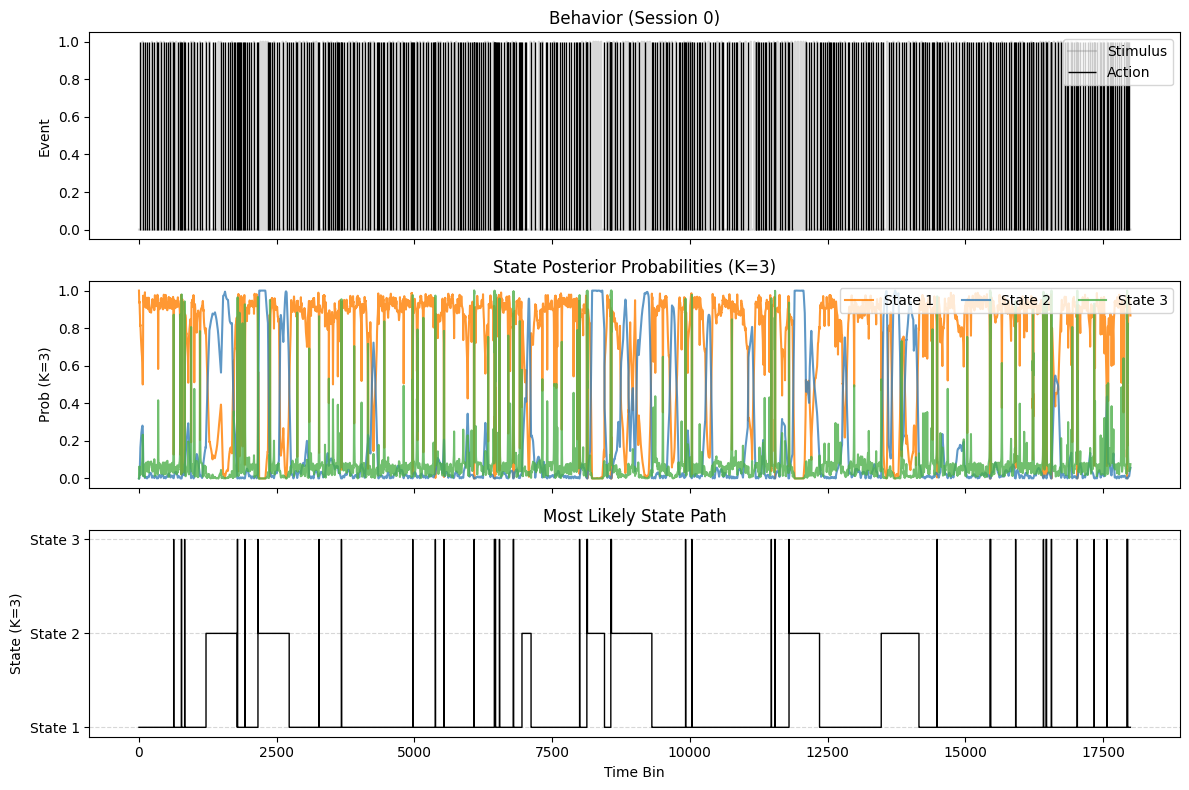

In [ ]:
# --- 3. 遷移確率行列 (Dynamic K) ---
# モデルから現在の状態数 K を取得
K = map_model.K

# 遷移行列の取得
trans_mat = np.exp(map_model.transitions.params)[0]

print(f"\nTransition Matrix (K={K}):")
print(np.round(trans_mat, 3))

# --- 4. 時系列でのState変化の可視化 ---
# サンプルセッションの取得
sess_idx = 0
y_true = train_ys[sess_idx]
x_in = train_xs[sess_idx]

# 推定 (Viterbi & Posterior)
z_est = map_model.most_likely_states(y_true, input=x_in)
prob_est = map_model.expected_states(data=y_true, input=x_in)[0]

# カラーパレットの安全策（前のセルで定義されていない場合用）
if 'colors' not in locals() or len(colors) < K:
    import matplotlib.pyplot as plt
    colors = plt.cm.tab10(np.linspace(0, 1, K))

# プロット
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
time_bins = np.arange(len(y_true))

# 1. 行動データ (Stimulus & Action)
# x_in[:, 1] は 'Stimulus' (0: Bias, 1: Stimulus, 2: Hist...)
axes[0].plot(time_bins, x_in[:, 1], color='gray', alpha=0.3, label="Stimulus")
axes[0].vlines(time_bins[y_true.flatten() == 1], 0, 1, color='black', linewidth=1, label="Action")
axes[0].set_title(f"Behavior (Session {sess_idx})")
axes[0].legend(loc="upper right")
axes[0].set_ylabel("Event")

# 2. 状態確率 (State Posterior Probabilities)
for k in range(K):
    axes[1].plot(time_bins, prob_est[:, k], label=f"State {k+1}", color=colors[k], alpha=0.8)

axes[1].set_ylabel(f"Prob (K={K})")
axes[1].set_title(f"State Posterior Probabilities (K={K})")
axes[1].legend(loc="upper right", ncol=min(K, 5)) # 状態数が多い場合は列を増やす可能性あり

# 3. Viterbi Path (Most Likely State)
axes[2].step(time_bins, z_est, where='post', color='black', linewidth=1)

# Y軸の設定を動的に変更 (0, 1, ..., K-1)
axes[2].set_ylabel(f"State (K={K})")
axes[2].set_yticks(np.arange(K))
axes[2].set_yticklabels([f"State {k+1}" for k in range(K)])
axes[2].set_title("Most Likely State Path")
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.xlabel("Time Bin")
plt.tight_layout()
plt.show()

Training GLM-HMM (K=2, M=13) with MAP Estimation (prior_sigma=2.0)...


  0%|          | 0/200 [00:00<?, ?it/s]

Seed 0: Final Score (Log Prob) = -1564.93


  0%|          | 0/200 [00:00<?, ?it/s]

Seed 1: Final Score (Log Prob) = -1534.26


  0%|          | 0/200 [00:00<?, ?it/s]

Seed 2: Final Score (Log Prob) = -1564.91

Recovered Weights with Regularization:
State 1 : [ 3.73 -0.37  1.12 -1.94 -0.3  -0.41  0.52  0.2  -0.1  -0.16  0.06 -0.08
 -0.41] ...
State 2 : [ 4.09 -0.46 10.04 -0.42 -0.3  -0.64 -0.51  0.    0.71 -0.53  0.6  -0.51
  0.7 ] ...


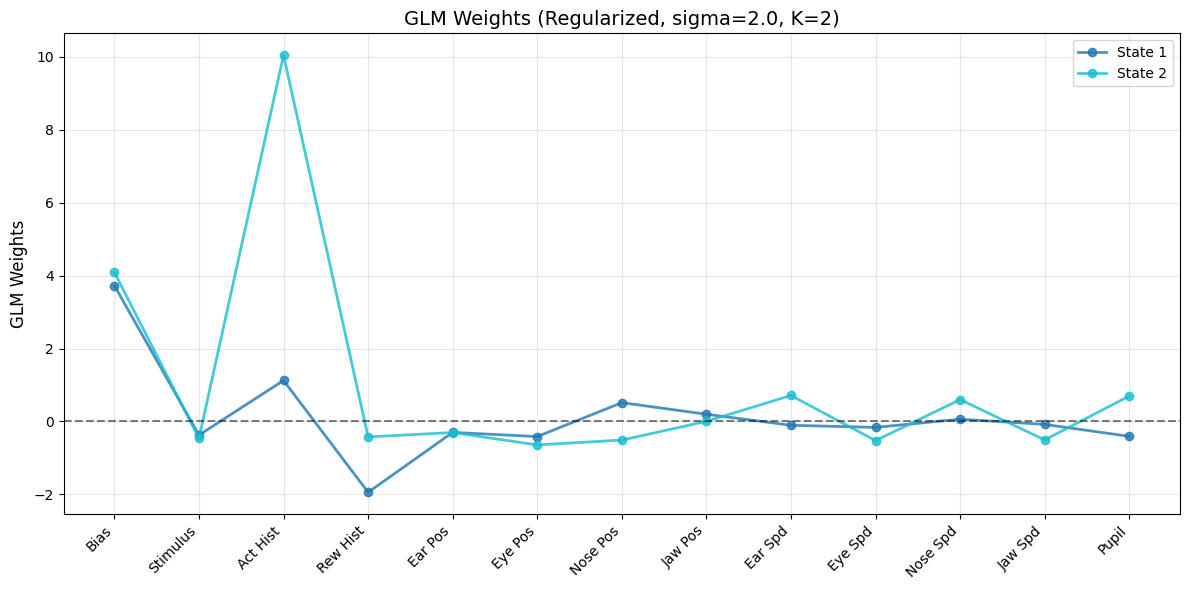


Transition Matrix:
[[0.975 0.025]
 [0.003 0.997]]


In [ ]:
import numpy as np
import ssm
import matplotlib.pyplot as plt
import seaborn as sns # 色の自動生成用（なければmatplotlibのcmapを使用）

def train_glmhmm_map(train_ys, train_xs, num_states=3, prior_sigma=2.0, num_iters=200, seeds=[0]):
    """
    L2正則化（MAP推定）を用いてGLM-HMMを学習する関数。
    入力次元数(M)はデータの形状から自動取得するように変更しています。
    """

    # 入力次元をデータから自動取得（Phase 3では13次元）
    obs_dim = 1
    input_dim = train_xs[0].shape[1]
    num_categories = 2

    best_model = None
    best_ll = -np.inf

    print(f"Training GLM-HMM (K={num_states}, M={input_dim}) with MAP Estimation (prior_sigma={prior_sigma})...")

    for seed in seeds:
        np.random.seed(seed)

        # observation_kwargs に prior_sigma を設定
        glmhmm = ssm.HMM(
            K=num_states,
            D=obs_dim,
            M=input_dim,
            observations="input_driven_obs",
            observation_kwargs=dict(
                C=num_categories,
                prior_mean=0,
                prior_sigma=prior_sigma
            ),
            transitions="standard"
        )

        try:
            lls = glmhmm.fit(train_ys, inputs=train_xs, method="em", num_iters=num_iters, tolerance=10**-4)

            final_score = lls[-1]
            print(f"Seed {seed}: Final Score (Log Prob) = {final_score:.2f}")

            if final_score > best_ll:
                best_ll = final_score
                best_model = glmhmm

        except Exception as e:
            print(f"Seed {seed} failed: {e}")
            continue

    if best_model is None:
        raise RuntimeError("Training failed.")

    return best_model

# --- 実行と確認 ---
try:
    # 状態数をPhase 3の要件に合わせて探索 (例: K=3)
    # 必要に応じて num_states=2 などに変更してください
    TARGET_K = 2
    map_model = train_glmhmm_map(train_ys, train_xs, num_states=TARGET_K, prior_sigma=2.0, seeds=[0, 1, 2])

    # --- 重みの確認 ---
    glm_weights_map = map_model.observations.params

    # Phase 3 の変数定義に対応したラベル（13次元）
    feature_names = [
        'Bias', 'Stimulus', 'Act Hist', 'Rew Hist',  # Base (4)
        'Ear Pos', 'Eye Pos', 'Nose Pos', 'Jaw Pos', # Position (4)
        'Ear Spd', 'Eye Spd', 'Nose Spd', 'Jaw Spd', # Speed (4)
        'Pupil'                                      # Pupil (1)
    ]

    # 次元数の整合性チェック
    if map_model.M != len(feature_names):
        print(f"Warning: Model dimension ({map_model.M}) does not match feature names ({len(feature_names)}).")
        # ラベルを汎用的なものに置き換え
        feature_names = [f'Feat {i}' for i in range(map_model.M)]

    # カラーパレットの作成（状態数に応じて自動調整）
    colors = plt.cm.tab10(np.linspace(0, 1, TARGET_K))

    print("\nRecovered Weights with Regularization:")
    for k in range(map_model.K):
        # 最初の5特徴量のみ表示（長くなるため）
        weights_preview = np.round(glm_weights_map[k][0][:], 2)
        print(f"State {k+1} : {weights_preview} ...")

    # プロット設定
    plt.figure(figsize=(12, 6)) # 横幅を広げる

    for k in range(map_model.K):
        w_k = glm_weights_map[k][0] # shape: (M,)
        plt.plot(range(len(feature_names)), w_k, marker='o',
                 label=f'State {k+1}', color=colors[k], linewidth=2, alpha=0.8)

    plt.axhline(0, color='black', linestyle='--', alpha=0.5)

    # X軸の設定（ラベルを回転させて重なりを防ぐ）
    plt.xticks(range(len(feature_names)), feature_names, fontsize=10, rotation=45, ha='right')

    plt.ylabel("GLM Weights", fontsize=12)
    plt.title(f"GLM Weights (Regularized, sigma={2.0}, K={TARGET_K})", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout() # レイアウト調整
    plt.show()

    # --- 遷移確率の確認 ---
    print("\nTransition Matrix:")
    print(np.round(np.exp(map_model.transitions.params)[0], 3))

except NameError:
    print("Error: 'train_ys' or 'train_xs' not found. Please load the dataset first.")
except Exception as e:
    print(f"An error occurred: {e}")


Transition Matrix (K=2):
[[0.975 0.025]
 [0.003 0.997]]


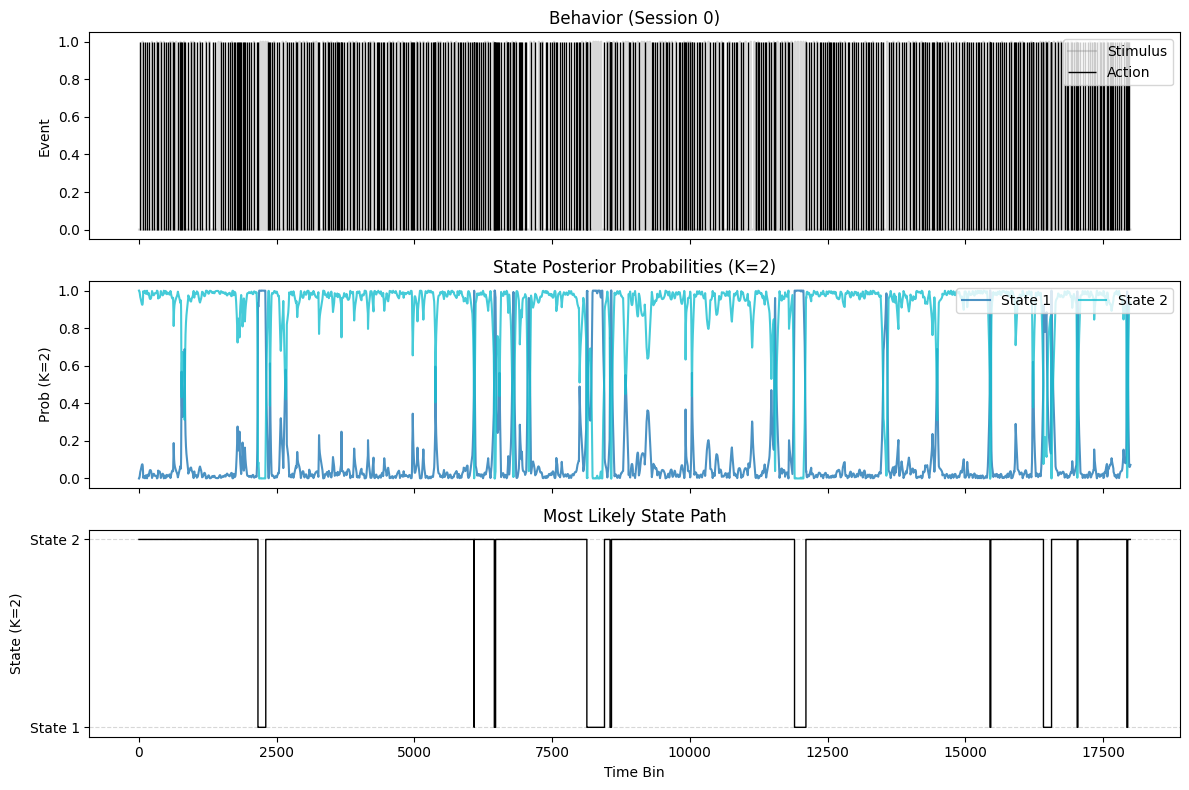

In [ ]:
# --- 3. 遷移確率行列 (Dynamic K) ---
# モデルから現在の状態数 K を取得
K = map_model.K

# 遷移行列の取得
trans_mat = np.exp(map_model.transitions.params)[0]

print(f"\nTransition Matrix (K={K}):")
print(np.round(trans_mat, 3))

# --- 4. 時系列でのState変化の可視化 ---
# サンプルセッションの取得
sess_idx = 0
y_true = train_ys[sess_idx]
x_in = train_xs[sess_idx]

# 推定 (Viterbi & Posterior)
z_est = map_model.most_likely_states(y_true, input=x_in)
prob_est = map_model.expected_states(data=y_true, input=x_in)[0]

# カラーパレットの安全策（前のセルで定義されていない場合用）
if 'colors' not in locals() or len(colors) < K:
    import matplotlib.pyplot as plt
    colors = plt.cm.tab10(np.linspace(0, 1, K))

# プロット
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
time_bins = np.arange(len(y_true))

# 1. 行動データ (Stimulus & Action)
# x_in[:, 1] は 'Stimulus' (0: Bias, 1: Stimulus, 2: Hist...)
axes[0].plot(time_bins, x_in[:, 1], color='gray', alpha=0.3, label="Stimulus")
axes[0].vlines(time_bins[y_true.flatten() == 1], 0, 1, color='black', linewidth=1, label="Action")
axes[0].set_title(f"Behavior (Session {sess_idx})")
axes[0].legend(loc="upper right")
axes[0].set_ylabel("Event")

# 2. 状態確率 (State Posterior Probabilities)
for k in range(K):
    axes[1].plot(time_bins, prob_est[:, k], label=f"State {k+1}", color=colors[k], alpha=0.8)

axes[1].set_ylabel(f"Prob (K={K})")
axes[1].set_title(f"State Posterior Probabilities (K={K})")
axes[1].legend(loc="upper right", ncol=min(K, 5)) # 状態数が多い場合は列を増やす可能性あり

# 3. Viterbi Path (Most Likely State)
axes[2].step(time_bins, z_est, where='post', color='black', linewidth=1)

# Y軸の設定を動的に変更 (0, 1, ..., K-1)
axes[2].set_ylabel(f"State (K={K})")
axes[2].set_yticks(np.arange(K))
axes[2].set_yticklabels([f"State {k+1}" for k in range(K)])
axes[2].set_title("Most Likely State Path")
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.xlabel("Time Bin")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# L2正則化済みのK=2モデル (map_model) に plot_session_time_series を適用
try:
    # sess_idx=0, duration_sec=1800 はデフォルト値
    plot_session_time_series(map_model, train_ys, train_xs, sess_idx=0, duration_sec=1800)
except NameError:
    print("モデル 'map_model' が見つかりません。学習コードを実行してください。")


モデル 'map_model' が見つかりません。学習コードを実行してください。


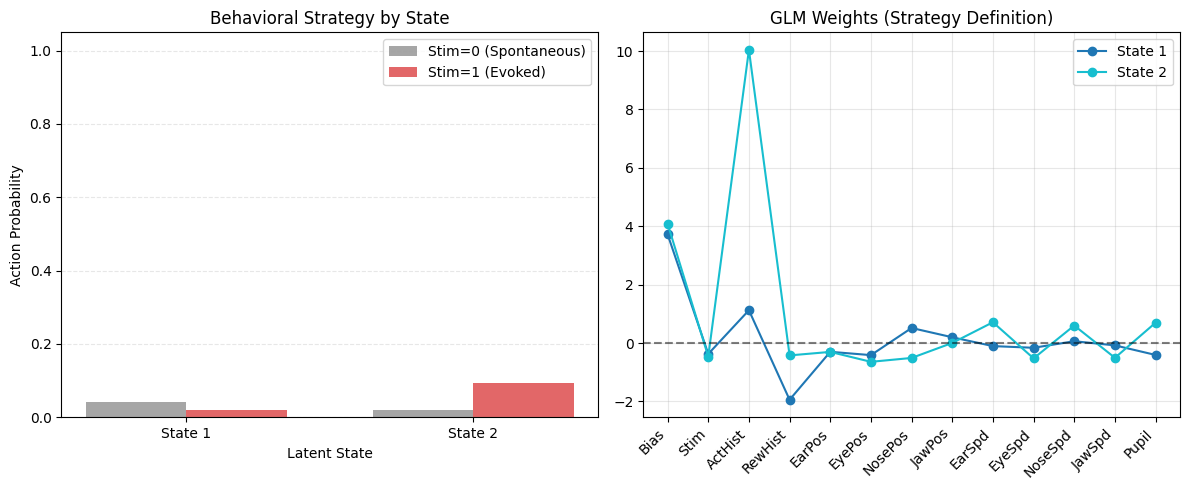

--- Behavioral Performance by State ---
State 1 | Hit Rate: 0.02,  FA Rate: 0.04
State 2 | Hit Rate: 0.09,  FA Rate: 0.02


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def validate_states(model, train_ys, train_xs, neural_data=None, neural_fs=30, bin_width=0.1):
    """
    学習した状態(State)が、行動戦略として妥当か、生体データと相関するかを検証する。
    Phase 3 (13次元入力, 可変K) 対応版。

    Parameters
    ----------
    neural_data : list of np.ndarray or None
        各セッションの生体データ（顔、蛍光輝度など）。
        形状は (T_raw, 1) または (T_raw, N_rois)。
        Noneの場合は行動解析のみ行う。
    """

    K = model.K

    # Phase 3 用の特徴量名定義 (13次元)
    feature_names_list = [
        'Bias', 'Stim', 'ActHist', 'RewHist',       # Base
        'EarPos', 'EyePos', 'NosePos', 'JawPos',    # Position
        'EarSpd', 'EyeSpd', 'NoseSpd', 'JawSpd',    # Speed
        'Pupil'                                     # Pupil
    ]

    # 特徴量数が合わない場合の安全策
    if model.M != len(feature_names_list):
        feature_names_list = [f'Feat {i}' for i in range(model.M)]

    # カラーパレットの生成 (状態数に合わせて自動調整)
    colors = plt.cm.tab10(np.linspace(0, 1, K))

    # 全セッションのデータを結合して解析
    concat_y = np.concatenate(train_ys)
    concat_x = np.concatenate(train_xs)

    # 全タイムビンの状態確率を取得
    # expected_states: list of (T, K)
    posterior_list = [model.expected_states(data=y, input=x)[0] for y, x in zip(train_ys, train_xs)]
    concat_posterior = np.concatenate(posterior_list)

    # 各ビンを最も確率の高い状態に割り当て (Hard assignment)
    state_assignment = np.argmax(concat_posterior, axis=1)

    # --- 1. 行動戦略の分離確認 (Psychometric Analysis) ---
    # Stateごとに、Stimulus=0/1 の時の Action確率を計算

    stimulus = concat_x[:, 1] # 2列目がStimulus (Phase 3の仕様)
    action = concat_y.flatten()

    plt.figure(figsize=(12, 5)) # 横幅を少し拡大

    # Bar plot: P(Action | Stimulus, State)
    bar_width = 0.8 / K  # 状態数に応じて幅を調整
    index = np.arange(K)

    p_act_stim0 = []
    p_act_stim1 = []

    # サブプロット1: 行動確率
    plt.subplot(1, 2, 1)

    # 描画用の一時リスト
    bars_stim0 = []
    bars_stim1 = []

    for k in range(K):
        # 状態 k にいるインデックス
        idx_k = (state_assignment == k)

        if np.sum(idx_k) == 0:
            p0, p1 = 0, 0
        else:
            # Stimulus = 0 (Spontaneous / False Alarm)
            idx_k_stim0 = idx_k & (stimulus == 0)
            p0 = np.mean(action[idx_k_stim0]) if np.sum(idx_k_stim0) > 0 else 0

            # Stimulus = 1 (Evoked / Hit Rate)
            idx_k_stim1 = idx_k & (stimulus == 1)
            p1 = np.mean(action[idx_k_stim1]) if np.sum(idx_k_stim1) > 0 else 0

        p_act_stim0.append(p0)
        p_act_stim1.append(p1)

    # プロット (見やすくするため配置を工夫)
    x = np.arange(K)
    width = 0.35

    plt.bar(x - width/2, p_act_stim0, width, label='Stim=0 (Spontaneous)', color='gray', alpha=0.7)
    plt.bar(x + width/2, p_act_stim1, width, label='Stim=1 (Evoked)', color='tab:red', alpha=0.7)

    plt.xlabel('Latent State')
    plt.ylabel('Action Probability')
    plt.title('Behavioral Strategy by State')
    plt.xticks(x, [f'State {k+1}' for k in range(K)])
    plt.legend()
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # --- 2. 重みの再確認 ---
    plt.subplot(1, 2, 2)
    glm_weights = model.observations.params

    for k in range(K):
        plt.plot(feature_names_list, glm_weights[k][0], marker='o', label=f"State {k+1}", color=colors[k])

    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.title('GLM Weights (Strategy Definition)')
    plt.xticks(rotation=45, ha='right') # ラベルを回転
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # テキスト出力 (Kに応じてループ)
    print("--- Behavioral Performance by State ---")
    for k in range(K):
        print(f"State {k+1} | Hit Rate: {p_act_stim1[k]:.2f},  FA Rate: {p_act_stim0[k]:.2f}")


    # --- 3. 生体データとの相関 (Optional) ---
    if neural_data is not None:
        print("\nAnalyzing Biological Signal correlation...")

        # 生体データのサンプリングレート合わせ (30Hz -> 10Hz)
        down_ratio = int(neural_fs * bin_width) # 30 * 0.1 = 3

        neural_downsampled_list = []
        for session_neural in neural_data:
            # 簡易的なダウンサンプリング (reshape & mean)
            n_bins = len(session_neural) // down_ratio
            if n_bins > 0:
                neural_ds = session_neural[:n_bins*down_ratio].reshape(n_bins, down_ratio, -1).mean(axis=1)
                neural_downsampled_list.append(neural_ds)
            else:
                neural_downsampled_list.append(np.empty((0, session_neural.shape[1])))

        # 結合 (データ長を行動データに合わせる)
        concat_neural_list = []
        for nd, y in zip(neural_downsampled_list, train_ys):
             length = min(len(nd), len(y))
             if length > 0:
                 concat_neural_list.append(nd[:length])

        if concat_neural_list:
            concat_neural = np.concatenate(concat_neural_list)

            # 状態ごとの平均活動レベルを計算
            mean_activities = []
            std_activities = [] # エラーバー用

            # 再度長さを確認して assignment をスライス
            total_len = len(concat_neural)
            current_assignment = state_assignment[:total_len]

            for k in range(K):
                idx_k = (current_assignment == k)
                if np.sum(idx_k) > 0:
                    mean_act = np.mean(concat_neural[idx_k], axis=0)
                    mean_activities.append(mean_act)
                else:
                    mean_activities.append(np.zeros(concat_neural.shape[1]))

            # プロット (ROIが1つの場合)
            if concat_neural.shape[1] == 1:
                plt.figure(figsize=(6, 4))
                plt.bar([f'State {k+1}' for k in range(K)],
                        [m[0] for m in mean_activities],
                        color=colors)
                plt.ylabel('Mean Neural/Face Activity (z-score)')
                plt.title('Biological Signal Amplitude by State')
                plt.grid(axis='y', linestyle='--', alpha=0.3)
                plt.show()
            else:
                print("Multiple ROIs detected. Mean activity per state:")
                for k in range(K):
                    print(f"State {k+1}: {mean_activities[k]}")
        else:
            print("Warning: Neural data could not be aligned (length mismatch).")

# 実行例
validate_states(map_model, train_ys, train_xs)

In [ ]:
import numpy as np

# L2正則化済みK=2モデルのGLM重みを取得
glm_weights = map_model.observations.params

# 特徴量名 (Action Historyを除く3つ)
# train_xs_no_hist が作成された際の keep_indices = [0, 1, 3] に対応
feature_names_no_hist = ['Bias', 'Stimulus','Action Hist', 'Reward Hist']

print("--- GLM Parameters (Weights) for K=2 States ---")
print(f"Model used: {'L2-Regularized K=2 Model'}")

for k in range(map_model.K):
    # ssmの重みは (K, 1, M) の形状で保存されているため、squeezeして (M,) にする
    weights_k = np.squeeze(glm_weights[k])

    print(f"\nState {k+1}:")
    for i, name in enumerate(feature_names_no_hist):
        print(f"  {name}: {weights_k[i]:.4f}")


--- GLM Parameters (Weights) for K=2 States ---
Model used: L2-Regularized K=2 Model

State 1:
  Bias: 3.7253
  Stimulus: -0.3728
  Action Hist: 1.1242
  Reward Hist: -1.9418

State 2:
  Bias: 4.0909
  Stimulus: -0.4616
  Action Hist: 10.0431
  Reward Hist: -0.4229


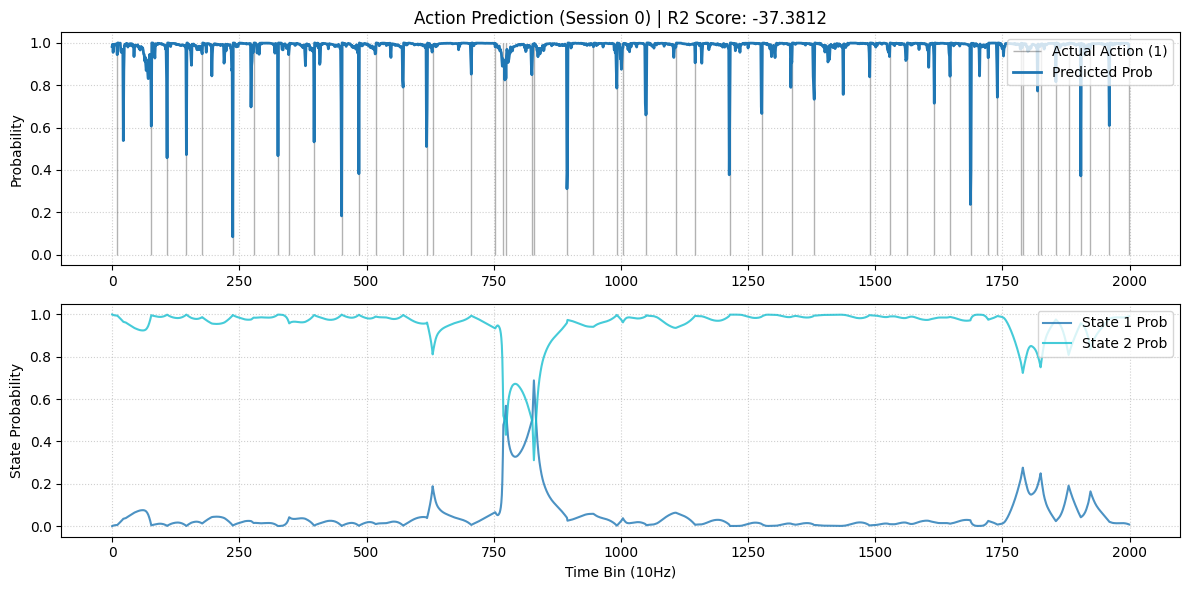

Calculating Global R2...
Global R2 Score (All Sessions): -37.3812


-37.38116047693354

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def evaluate_prediction_performance(model, train_ys, train_xs, sess_idx=0):
    """
    GLM-HMMの予測精度を評価し、時系列で可視化する関数。

    Parameters
    ----------
    model : ssm.HMM
        学習済みモデル
    train_ys : list of ndarray
        行動データ
    train_xs : list of ndarray
        入力データ
    sess_idx : int
        可視化対象のセッションインデックス
    """

    # 1. データ取得
    y_true = train_ys[sess_idx].flatten() # (T,)
    x_in = train_xs[sess_idx]             # (T, M)

    # 2. 状態事後確率の計算 (Posterior: Gamma)
    # shape: (T, K)
    expected_states = model.expected_states(data=y_true[:, None], input=x_in)[0]

    # 3. 各状態における行動確率の計算 (GLM output)
    # Weights shape: (K, D, M) -> (K, M) for D=1
    weights = np.squeeze(model.observations.params)
    if model.K == 1: weights = weights[np.newaxis, :] # K=1対応

    # Logits = X @ W.T -> (T, K)
    logits = np.dot(x_in, weights.T)

    # Sigmoid function -> (T, K)
    probs_per_state = 1 / (1 + np.exp(-logits))

    # 4. 最終的な予測確率 (Marginal Probability)
    # P(y) = sum_k P(y|z=k) * P(z=k)
    # element-wise multiplication and sum over states
    y_pred = np.sum(probs_per_state * expected_states, axis=1)

    # 5. R2スコアの算出
    # 注: バイナリデータに対する連続値予測のR2は低くなりやすいため、参考値として扱います
    r2_val = r2_score(y_true, y_pred)

    # 6. 可視化
    T_plot = min(len(y_true), 2000) # 最初の500ビン(50秒)を表示
    time_bins = np.arange(T_plot)

    plt.figure(figsize=(12, 6))

    # 上段: 予測確率と真の値
    ax1 = plt.subplot(2, 1, 1)
    # 真の行動 (スパイクとして表示)
    ax1.vlines(time_bins[y_true[:T_plot] == 1], 0, 1, color='black', alpha=0.3, linewidth=1, label='Actual Action (1)')
    # 予測確率 (曲線)
    ax1.plot(time_bins, y_pred[:T_plot], color='tab:blue', linewidth=2, label='Predicted Prob')

    ax1.set_ylabel('Probability')
    ax1.set_title(f'Action Prediction (Session {sess_idx}) | R2 Score: {r2_val:.4f}')
    ax1.legend(loc='upper right')
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, linestyle=':', alpha=0.6)

    # 下段: 予測に寄与している状態確率 (参考)
    ax2 = plt.subplot(2, 1, 2, sharex=ax1)
    colors = plt.cm.tab10(np.linspace(0, 1, model.K))
    for k in range(model.K):
        ax2.plot(time_bins, expected_states[:T_plot, k], label=f'State {k+1} Prob', color=colors[k], alpha=0.8)

    ax2.set_ylabel('State Probability')
    ax2.set_xlabel('Time Bin (10Hz)')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

    return r2_val, y_true, y_pred

# --- 全セッションのR2を確認 ---
def calculate_global_r2(model, train_ys, train_xs):
    all_y_true = []
    all_y_pred = []

    weights = np.squeeze(model.observations.params)
    if model.K == 1: weights = weights[np.newaxis, :]

    print("Calculating Global R2...")
    for y, x in zip(train_ys, train_xs):
        # Posterior
        expected_states = model.expected_states(data=y, input=x)[0]
        # GLM Probs
        logits = np.dot(x, weights.T)
        probs_per_state = 1 / (1 + np.exp(-logits))
        # Marginal
        y_pred = np.sum(probs_per_state * expected_states, axis=1)

        all_y_true.append(y.flatten())
        all_y_pred.append(y_pred)

    global_true = np.concatenate(all_y_true)
    global_pred = np.concatenate(all_y_pred)

    global_r2 = r2_score(global_true, global_pred)
    print(f"Global R2 Score (All Sessions): {global_r2:.4f}")
    return global_r2

# 実行
# 特定セッションの可視化
r2, true_vals, pred_vals = evaluate_prediction_performance(map_model, train_ys, train_xs, sess_idx=0)

# 全体の精度確認
calculate_global_r2(map_model, train_ys, train_xs)